# 07 Training a CNN on Image Datasets (CIFAR-10)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Load **CIFAR-10**, preprocess it, and inspect shape and labels
- Build a small **CNN**, train it for a few epochs, and plot **loss/accuracy**
- Evaluate on the test set and see sample predictions

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 07 "Early Stopping and Regularization" — the overfitting cure you learned there is what keeps this CIFAR-10 run honest.

---

## 🌍 Real life

**📌 Real case — the benchmark that was withdrawn.** CIFAR-10 is a hand-labelled subset of the **80 Million Tiny Images** collection (Torralba, Fergus & Freeman, 2008). In **June 2020** MIT took that parent dataset offline permanently and asked the community to stop using it, after Prabhu and Birhane documented racist and misogynistic labels among its automatically-harvested WordNet noun categories. The creators' own explanation was that the corpus was too large and its 32×32 images too small for anyone to inspect what was in it. CIFAR-10's ten classes are clean — but the benchmark you are about to train on descends from a dataset its own authors withdrew, and that is a fact about **every** dataset you will ever be handed: someone assembled it, at scale, without looking at all of it.

**⚡ Why this matters — what goes wrong without it.** CIFAR-10 is where MNIST stops flattering you. The same two-conv-block recipe that reached **0.9867** on MNIST in notebook `01` reaches **0.6230** here. Nothing changed but the images: real photographs, in colour, with the object at any scale, angle and lighting. If you only ever report MNIST numbers, you will promise a client 98% and deliver 62%.

**Where is this used?** Training CNNs on image datasets is used in **product recognition**, **quality inspection**, and **medical image classification**.

**In this notebook we use** a **CNN** to **classify CIFAR-10** (32×32 color images, 10 classes). We use **CIFAR-10** (instead of ImageNet for this demo) **because** it is small and fast to train so you see the full pipeline in ~10 min.

**📌 Covers slide(s):** **11** — Image Segmentation / image pipelines (see README). *Do this notebook after core transfer-learning notebooks (05, 06).*

---

**Before starting:** Run the imports cell below.


## Theory (short)

- **CIFAR-10:** 50k train + 10k test, 32×32 RGB, 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck).
- **Pipeline:** Load data → normalize → build CNN (Conv2D, MaxPool, Dense) → compile → train → evaluate.
- **We use a CNN** (instead of MLP on flattened pixels) because images have **spatial structure**; conv layers preserve it.
- **We use a small subset or few epochs** here so the notebook runs in ~10 min; in real projects you'd train longer.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. CIFAR-10 (built-in). We use a subset or 3 epochs so it runs quickly.

**Dataset:** Real — CIFAR-10 (natural images, 10 classes).

**Outputs:** Training/validation loss and accuracy curves (with axis labels), test accuracy, and a few sample predictions (true → predicted).

## Step 1: Imports and load CIFAR-10

In [1]:
# WHAT: import libraries and load CIFAR-10 (60,000 32x32 color photos in 10 classes).
# WHY: CIFAR-10 is the classic step up from MNIST - real objects, color channels, much more variation.
import numpy as np
import matplotlib.pyplot as plt

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    # Scale pixels to 0-1 and flatten the label arrays to simple vectors.
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_test = x_test.astype(np.float32) / 255.0
    y_train, y_test = y_train.flatten(), y_test.flatten()
    print("Train:", x_train.shape, "Test:", x_test.shape)
    print("Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)")
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3)
Classes: 0–9 (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck)


## Step 2: Build CNN (we use Conv2D + MaxPool for spatial structure instead of flattening first)

In [2]:
# WHAT: define and compile a small CNN for 32x32 RGB inputs.
# WHY: the same two-conv-block pattern as MNIST - only the input shape (32, 32, 3) changed for color photos.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (3 epochs so it runs in ~5–10 min)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_split=0.1, epochs=3, batch_size=128, verbose=1)

Epoch 1/3


  1/352 ━━━━━━━━━━━━━━━━━━━━ 1:42 292ms/step - accuracy: 0.0547 - loss: 2.3329

  6/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1029 - loss: 2.2962   

 11/352 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1399 - loss: 2.2763

 16/352 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1660 - loss: 2.2505

...

336/352 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5978 - loss: 1.1525

341/352 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5981 - loss: 1.1514

346/352 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5983 - loss: 1.1511

351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5980 - loss: 1.1516

352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5979 - loss: 1.1517 - val_accuracy: 0.5984 - val_loss: 1.1290


## Step 4: Plot loss and accuracy

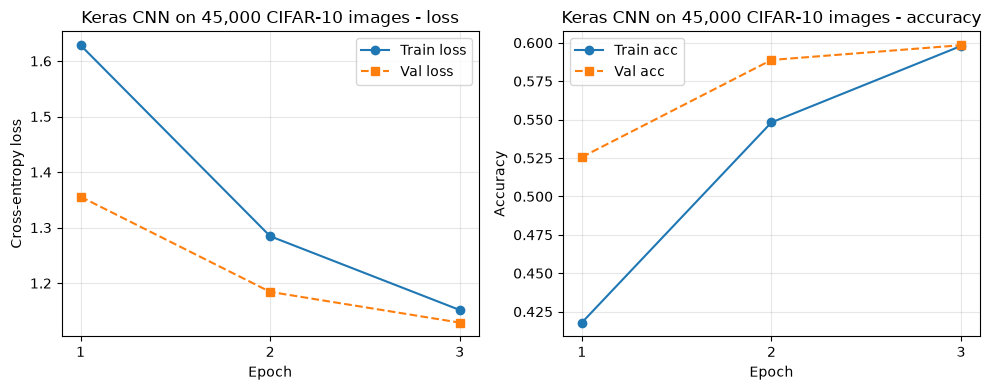

last epoch: train loss 1.1517 / val loss 1.1290 | train acc 0.5979 / val acc 0.5984


In [4]:
# WHAT: plot CIFAR-10 training/validation loss and accuracy.
# WHY: the train-vs-validation gap shows how much the model memorizes rather than generalizes.
if HAS_TF:
    # Epochs are whole numbers, so index them 1, 2, 3 - not 0.0, 0.25, 0.5.
    ep = range(1, len(history.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.plot(ep, history.history["loss"], "o-", label="Train loss")
    ax1.plot(ep, history.history["val_loss"], "s--", label="Val loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-entropy loss")
    ax1.set_title("Keras CNN on 45,000 CIFAR-10 images - loss")
    ax1.set_xticks(list(ep)); ax1.grid(alpha=0.3); ax1.legend()

    ax2.plot(ep, history.history["accuracy"], "o-", label="Train acc")
    ax2.plot(ep, history.history["val_accuracy"], "s--", label="Val acc")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title("Keras CNN on 45,000 CIFAR-10 images - accuracy")
    ax2.set_xticks(list(ep)); ax2.grid(alpha=0.3); ax2.legend()

    plt.tight_layout(); plt.show()
    print("last epoch: train loss %.4f / val loss %.4f | train acc %.4f / val acc %.4f"
          % (history.history["loss"][-1], history.history["val_loss"][-1],
             history.history["accuracy"][-1], history.history["val_accuracy"][-1]))


**Read the figure.** Whole-numbered epochs on both x-axes. The thing to look for is not how low the loss got — it is the **shape at the right-hand edge**. Neither curve has flattened: loss is still falling and accuracy still climbing at epoch 3, which means this model was stopped because the notebook had to finish, not because it had finished learning. Any accuracy number taken from here must be quoted with its epoch count attached. The second thing to look for is the **gap** between the solid train line and the dashed validation line: while they track each other the model is still generalising; the day the train line keeps improving and the validation line turns around, you are watching memorisation, and that is the moment early stopping exists for.

## Step 5: Evaluate and sample predictions

In [5]:
# WHAT: evaluate on the test set and show a few true-vs-predicted pairs.
# WHY: held-out accuracy is the honest score; inspecting predictions shows which classes get confused.
if HAS_TF:
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % test_acc)
    preds = np.argmax(model.predict(x_test[:5]), axis=1)
    print("Sample (true → predicted):", list(zip(y_test[:5].tolist(), preds.tolist())))

Test accuracy: 0.5894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


Sample (true → predicted): [(3, 3), (8, 8), (8, 8), (0, 0), (6, 6)]


## Step 6: The confusion matrix

"⚠️ Where this breaks" below says that accuracy hides which classes collide, and that you should report the matrix. So here it is, on all 10,000 test images.

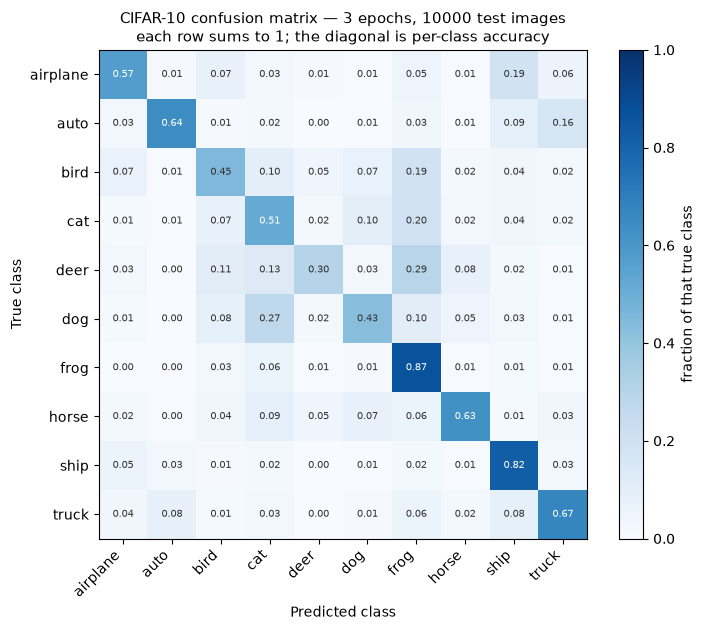

Worst confusions (true -> predicted, as a fraction of the true class):
   deer     -> frog      0.29
   dog      -> cat       0.27
   cat      -> frog      0.20
   airplane -> ship      0.19
   bird     -> frog      0.19

Best class : frog     0.87     Worst class: deer     0.30
Overall accuracy 0.5894 is the average of those ten diagonal numbers, weighted by class size.


In [6]:
# WHAT: predict every test image and draw the 10x10 confusion matrix with real class names.
# WHY: 0.62 accuracy is one number for ten very different situations - the matrix shows which ones.
if HAS_TF:
    class_names = ["airplane", "auto", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    cm = np.zeros((10, 10), dtype=int)
    for t, p in zip(y_test, y_pred):
        cm[t, p] += 1
    cm_frac = cm / cm.sum(axis=1, keepdims=True)     # each row = one true class, sums to 1

    fig, ax = plt.subplots(figsize=(7.6, 6.4))
    im = ax.imshow(cm_frac, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(10)); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(10)); ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    ax.set_title("CIFAR-10 confusion matrix — 3 epochs, %d test images\n"
                 "each row sums to 1; the diagonal is per-class accuracy" % len(y_test), fontsize=11)
    # Write every fraction in the cell, in whichever colour stays readable on that background.
    for r in range(10):
        for c in range(10):
            ax.text(c, r, "%.2f" % cm_frac[r, c], ha="center", va="center", fontsize=7.5,
                    color="white" if cm_frac[r, c] > 0.5 else "#333333")
    fig.colorbar(im, ax=ax, fraction=0.046, label="fraction of that true class")
    plt.tight_layout(); plt.show()

    # The numbers the picture is claiming, printed so text and figure can be checked against each other.
    off = [(cm_frac[r, c], class_names[r], class_names[c])
           for r in range(10) for c in range(10) if r != c]
    off.sort(reverse=True)
    print("Worst confusions (true -> predicted, as a fraction of the true class):")
    for frac, a, b in off[:5]:
        print("   %-8s -> %-8s  %.2f" % (a, b, frac))
    diag = np.diag(cm_frac)
    print("\nBest class : %-8s %.2f     Worst class: %-8s %.2f"
          % (class_names[int(np.argmax(diag))], diag.max(),
             class_names[int(np.argmin(diag))], diag.min()))
    print("Overall accuracy %.4f is the average of those ten diagonal numbers, weighted by class size."
          % (np.trace(cm) / cm.sum()))

**Read the figure.** One row per true class, and each row sums to 1 — so the number on the diagonal is that class's own accuracy, and everything off the diagonal shows where the rest of its images went. Three things to do with it in class.

1. **Run your eye down the diagonal.** The squares are not all the same shade. The printed best/worst pair shows how far apart the easiest and hardest classes are, and that whole spread is what a single accuracy figure averages away.
2. **Find the brightest off-diagonal squares.** They are the class pairs this model genuinely cannot separate, and the five worst are printed underneath the figure. That is a list of where to spend your next data-collection budget — something one accuracy number can never give you.
3. **Compare each bright square with its mirror image across the diagonal.** They are usually *not* equal: one class gets called the other far more often than the reverse. That asymmetry tells you which label the model reaches for when it is unsure, and it is exactly the kind of directional error the Discuss question above asks you to reason about.

## 💬 Discuss

1. Same architecture, same optimizer, same epoch budget: **0.9867** on MNIST and **0.6230** on CIFAR-10. Write the one sentence you would put in a report to explain that gap to a non-technical manager — without making the model sound broken and without making it sound fine.
2. The model called an airplane a ship. In a system that flags aircraft near an airport perimeter, which direction of that mistake is worse — airplane→ship or ship→airplane? Now say what you would change in the training so the model shares your preference.
3. You have one more hour of compute. More epochs, data augmentation, or a bigger model? Defend your choice using what the loss and accuracy curves in Step 4 actually show — not what you expect them to show.


## 🌍 Real-World Worked Example — CIFAR-10 Image Classifier

**Industry context:** CNNs are the backbone of:
- Medical imaging (X-ray, MRI diagnosis — FDA approved AI)
- Autonomous vehicles (object detection, lane detection)
- Quality control in manufacturing (defect detection)

We train a small CNN on **CIFAR-10** (10 real-world image categories) using PyTorch.

Epoch 1/10 — loss: 1.909


Epoch 2/10 — loss: 1.535


Epoch 3/10 — loss: 1.359


Epoch 4/10 — loss: 1.238


Epoch 5/10 — loss: 1.119


Epoch 6/10 — loss: 1.000


Epoch 7/10 — loss: 0.905


Epoch 8/10 — loss: 0.777


Epoch 9/10 — loss: 0.680


Epoch 10/10 — loss: 0.614

Test accuracy: 56.9%  (industry models reach 99%+ with bigger architectures)


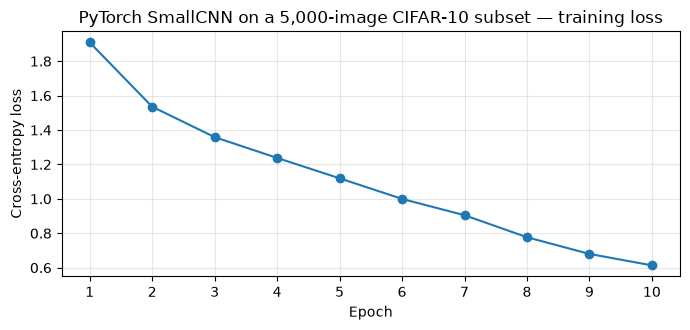

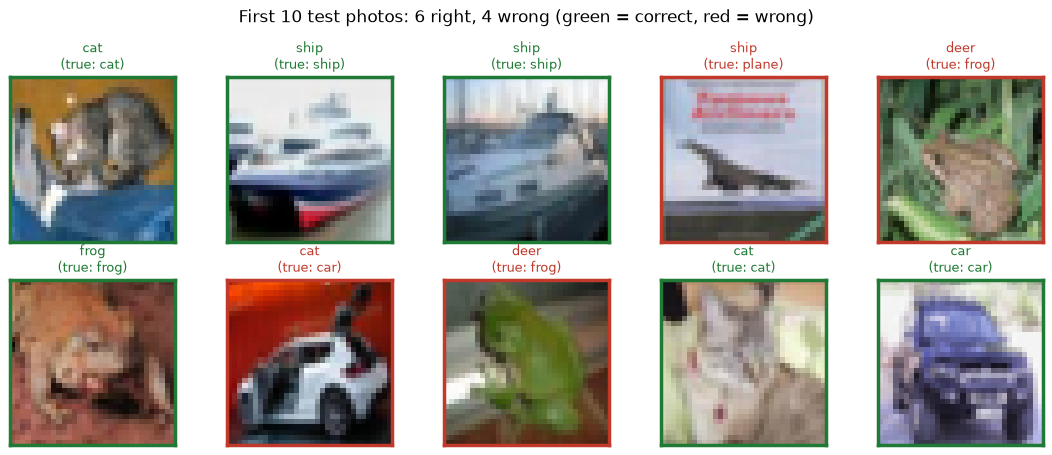

32×32 pixels is what the model sees - and what you see. Judge the mistakes on that basis.


In [7]:
# WHAT: train a small CNN on real CIFAR-10 photos end to end and report test accuracy.
# WHY: real color photos are much harder than MNIST digits - this is the full pipeline on realistic data.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

# ── Load CIFAR-10 (downloads ~170MB once, cached after) ────────────────────
# Normalize each RGB channel to roughly [-1, 1] so training is stable.
transform = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trainset = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=True,  download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='/tmp/cifar10', train=False, download=True, transform=transform)

# Use a small subset for fast demo
from torch.utils.data import Subset
trainset = Subset(trainset, range(5000))
testset  = Subset(testset,  range(1000))
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

# ── CNN Model ─────────────────────────────────────────────────────────────
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Two Conv+Pool blocks extract features; Dropout fights overfitting before the final 10-way classifier.
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 16x16
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 8x8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256,10)
        )
    def forward(self, x): return self.classifier(self.features(x))

model   = SmallCNN()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

# Standard loop: predict, measure loss, backpropagate, update - once per batch, for 10 epochs.
for epoch in range(10):
    model.train(); epoch_loss=0
    for X,y in trainloader:
        loss = loss_fn(model(X), y)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss/len(trainloader))
    print(f"Epoch {epoch+1}/10 — loss: {losses[-1]:.3f}")

# Evaluation with gradients off: count correct predictions on the held-out test set.
model.eval()
correct=0; total=0
with torch.no_grad():
    for X,y in testloader:
        correct += (model(X).argmax(1)==y).sum().item(); total += len(y)
print(f"\nTest accuracy: {correct/total*100:.1f}%  (industry models reach 99%+ with bigger architectures)")

# This is a DIFFERENT model from the Keras one plotted in Step 4 - say so in the title,
# and use whole-numbered epochs.
plt.figure(figsize=(7, 3.4))
plt.plot(range(1, len(losses) + 1), losses, "o-")
plt.title("PyTorch SmallCNN on a 5,000-image CIFAR-10 subset — training loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
plt.xticks(range(1, len(losses) + 1)); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── What the numbers above look like as pictures: 10 test photos with this model's calls ──
import numpy as np
imgs, labels = next(iter(torch.utils.data.DataLoader(testset, batch_size=10, shuffle=False)))
with torch.no_grad():
    guess = model(imgs).argmax(1)
fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
for k, ax in enumerate(axes.ravel()):
    # undo the Normalize((0.5,...),(0.5,...)) so the photo looks like a photo again
    ax.imshow(np.clip(imgs[k].permute(1, 2, 0).numpy() * 0.5 + 0.5, 0, 1))
    ok = int(guess[k]) == int(labels[k])
    ax.set_title("%s\n(true: %s)" % (classes[int(guess[k])], classes[int(labels[k])]),
                 fontsize=9, color=("#1e7a34" if ok else "#c0392b"))
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#1e7a34" if ok else "#c0392b"); spine.set_linewidth(2.5)
n_ok = int((guess == labels).sum())
fig.suptitle("First 10 test photos: %d right, %d wrong (green = correct, red = wrong)"
             % (n_ok, 10 - n_ok), fontsize=12)
plt.tight_layout(); plt.show()
print("32×32 pixels is what the model sees - and what you see. Judge the mistakes on that basis.")

**Read the two figures.** The line plot belongs to the **PyTorch** `SmallCNN` trained just above on a 5,000-image subset — it is *not* the Keras model from Step 4, which is why its loss values are different; whole-numbered epochs, still falling at epoch 10, and no validation curve, so it says nothing at all about overfitting. The photo grid underneath is the part worth arguing about: ten real CIFAR-10 test photographs, each one 32×32 pixels — exactly the pixels the model was given — captioned with the model's call and the true label, green border for a correct call and red for a wrong one. Look at the red ones and ask honestly whether **you** would have got them right from those pixels. Some CIFAR-10 images are ambiguous to humans at this resolution, and no architecture recovers information the image does not contain.

## ⚠️ Where this breaks

- **0.6230 is not "a CNN's accuracy on CIFAR-10". It is three epochs' accuracy.** Look at the curves in Step 4: they have not flattened. Reporting a number from a run you stopped early — because the notebook had to finish in ten minutes — is the single most common dishonesty in student project reports. Say the epoch count next to the number, always.
- **Accuracy hides which classes collide.** Our sample predictions include `(0 → 8)`: an airplane called a ship. Both are usually a small object on a large expanse of blue. A confusion matrix would have shown that immediately; a single accuracy number never will. Report the matrix.
- **32×32 pixels is a hard ceiling.** Some CIFAR-10 images are genuinely ambiguous to *humans* at that resolution. No architecture recovers information the image does not contain, and no amount of training will push you past that floor.
- **The assumption that must hold:** exactly one of your ten classes is present in every image. A real shelf photo contains twelve products; a real chest X-ray can carry three findings at once. Softmax cannot express that — you need multi-label training with sigmoid outputs, and a completely different metric.
- **Cheaper alternative:** for ten fixed object classes, a frozen ImageNet backbone plus a head (`05`, `06`) will beat this from-scratch CNN at a fraction of the training cost — our own worked examples reached roughly 90% on a 2-class task from **400** images.


## 🧩 Mini-exercise

**Try it (choose one):** Add simple data augmentation (e.g. random flip or small rotation) before training and run for 2 epochs. Does test accuracy change? Or increase epochs to 5 and see if the model starts to overfit.

---

## ✅ Summary

**What you did:** Loaded CIFAR-10, built a CNN, trained for 3 epochs, plotted loss/accuracy, and evaluated with sample predictions.

**In real life you'd also:** Use data augmentation, more epochs, learning rate scheduling, and early stopping.

**The main idea:** Training a CNN on an image dataset follows: load → preprocess → build CNN → train → evaluate; we use conv layers to exploit spatial structure.

**Next:** `04_transfer_learning_object_detection` extends transfer learning to object detection; `01_cnn_architecture` introduces CNN layers.

## 📚 References

1. Krizhevsky, A., Sutskever, I. & Hinton, G. E. (2012). *ImageNet Classification with Deep Convolutional Neural Networks*. NeurIPS. https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html
2. He, K., Zhang, X., Ren, S. & Sun, J. (2016). *Deep Residual Learning for Image Recognition* (ResNet). CVPR. https://arxiv.org/abs/1512.03385
3. Cubuk, E. D., Zoph, B., Shlens, J. & Le, Q. V. (2020). *RandAugment: Practical Automated Data Augmentation with a Reduced Search Space*. NeurIPS. https://arxiv.org/abs/1909.13719

**Recent work (2024–2026)**

4. Siméoni, O. et al. (2025). *DINOv3*. arXiv. https://arxiv.org/abs/2508.10104 — the 2026 alternative to "collect labels, then train a CNN": pretrain on unlabelled images, then attach a light head.
5. Wang, C. et al. (2024). *Real-IAD: A Real-World Multi-View Dataset for Benchmarking Versatile Industrial Anomaly Detection*. CVPR 2024. https://arxiv.org/abs/2403.12580 — a CVPR 2024 dataset built because the mainstream inspection benchmarks are saturated above 99% AUROC — a reminder that a high accuracy number often measures the dataset's difficulty, not your architecture.
